# E-Commerce Recommendation Engine

## Phase 0: Setup & Libraries Installation

In [13]:
!pip install pandas numpy scikit-learn scikit-surprise matplotlib seaborn torch transformers datasets ipywidgets

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/d9/8d/40ac32e703f3808159f9e2b33760cfbd6224cc7783eb663091eddc9581c2/scikit_surprise-1.1.4.tar.gz#sha256=130c45feaee9de4b8cba0aff413ad9b51b2d5c5c90d41aee4759e00059913752 (from https://pypi.org/simple/scikit-surprise/) (requires-python:>=3.8): Requested unknown from https://files.pythonhosted.org/packages/d9/8d/40ac32e703f3808159f9e2b33760cfbd6224cc7783eb663091eddc9581c2/scikit_surprise-1.1.4.tar.gz#sha256=130c45feaee9de4b8cba0aff413ad9b51b2d5c5c90d41aee4759e00059913752 has inconsistent name: filename has 'scikit-surprise', but metadata has 'unknown'
  Using cached scikit-surpr

Failed to build scikit-surprise
  Running setup.py install for scikit-surprise ... error
  error: subprocess-exited-with-error
  
  × Running setup.py install for scikit-surprise did not run successfully.
  │ exit code: 1
  ╰─> [80 lines of output]
      running install
      /usr/lib/python3/dist-packages/setuptools/command/install.py:34: SetuptoolsDeprecationWarning: setup.py install is deprecated. Use build and pip and other standards-based tools.
        warnings.warn(
      running build
      running build_py
      creating build
      creating build/lib.linux-x86_64-3.10
      creating build/lib.linux-x86_64-3.10/surprise
      copying surprise/reader.py -> build/lib.linux-x86_64-3.10/surprise
      copying surprise/dump.py -> build/lib.linux-x86_64-3.10/surprise
      copying surprise/builtin_datasets.py -> build/lib.linux-x86_64-3.10/surprise
      copying surprise/accuracy.py -> build/lib.linux-x86_64-3.10/surprise
      copying surprise/dataset.py -> build/lib.linux-x86_64-3

In [8]:
!pip uninstall -y pandas numpy matplotlib seaborn
!pip install numpy==1.23.5 pandas==1.5.3 matplotlib==3.6.3 seaborn==0.12.2

Found existing installation: pandas 2.0.3
Uninstalling pandas-2.0.3:
  Successfully uninstalled pandas-2.0.3
Found existing installation: numpy 1.24.3
Uninstalling numpy-1.24.3:
  Successfully uninstalled numpy-1.24.3
Found existing installation: matplotlib 3.7.2
Uninstalling matplotlib-3.7.2:
  Successfully uninstalled matplotlib-3.7.2
Found existing installation: seaborn 0.12.2
Uninstalling seaborn-0.12.2:
  Successfully uninstalled seaborn-0.12.2
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 544.8 kB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 725.3 kB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 535.6 kB/s eta 0:00:00m eta 0:00:010:00:01
  Using cached seaborn-0.12.2-py3-none-any.whl (293 kB)


In [17]:
!pip install scikit-surprise

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Discarding https://files.pythonhosted.org/packages/d9/8d/40ac32e703f3808159f9e2b33760cfbd6224cc7783eb663091eddc9581c2/scikit_surprise-1.1.4.tar.gz#sha256=130c45feaee9de4b8cba0aff413ad9b51b2d5c5c90d41aee4759e00059913752 (from https://pypi.org/simple/scikit-surprise/) (requires-python:>=3.8): Requested unknown from https://files.pythonhosted.org/packages/d9/8d/40ac32e703f3808159f9e2b33760cfbd6224cc7783eb663091eddc9581c2/scikit_surprise-1.1.4.tar.gz#sha256=130c45feaee9de4b8cba0aff413ad9b51b2d5c5c90d41aee4759e00059913752 has inconsistent name: filename has 'scikit-surprise', but metadata has 'unknown'
  Using cached scikit-surprise-1.1.3.tar.gz (771 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-surprise

In [26]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)


## Phase 1: Setup & Imports

In [1]:
import pandas as pd
import os
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 2: Data Loading

In [ ]:
# # Create data directory
# os.makedirs(os.path.expanduser('~/Desktop/Hireable/data/'), exist_ok=True)

# # Download dataset using wget
# !wget -O ~/Desktop/Hireable/data/amazon_reviews.csv.gz https://snap.stanford.edu/data/finefoods.txt.gz

# # Extract the file
# !gunzip ~/Desktop/Hireable/data/amazon_reviews.csv.gz

--2026-01-15 11:06:46--  https://snap.stanford.edu/data/finefoods.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 122104202 (116M) [application/x-gzip]
Saving to: ‘/home/zigron/Desktop/Hireable/data/amazon_reviews.csv.gz’

/home/zigron/Deskto 100%[===================>] 116.45M   194KB/s    in 13m 25s 

2026-01-15 11:20:14 (148 KB/s) - ‘/home/zigron/Desktop/Hireable/data/amazon_reviews.csv.gz’ saved [122104202/122104202]

gzip: /home/zigron/Desktop/Hireable/data/amazon_reviews.csv already exists; do you wish to overwrite (y or n)? 

## Phase 3: Exploratory Data Analysis (EDA)

In [2]:
# Parse the file correctly
data = []
entry = {}

with open(os.path.expanduser('~/Desktop/Hireable/data/amazon_reviews.csv'), 'r', encoding='latin1') as f:
    for line in f:
        line = line.strip()
        colon_pos = line.find(':')
        
        if colon_pos == -1:  # No colon means end of review entry
            if entry:
                data.append(entry)
                entry = {}
            continue
        
        # Split at first colon
        key = line[:colon_pos]
        value = line[colon_pos+2:]  # Skip ': '
        entry[key] = value
    
    # Add last entry
    if entry:
        data.append(entry)

# Convert to DataFrame
df = pd.DataFrame(data)

# Display info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
df

Dataset shape: (568461, 8)

Columns: ['product/productId', 'review/userId', 'review/profileName', 'review/helpfulness', 'review/score', 'review/time', 'review/summary', 'review/text']

First few rows:
  product/productId   review/userId               review/profileName  \
0        B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1        B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2        B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3        B000UA0QIQ  A395BORC6FGVXV                             Karl   
4        B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

  review/helpfulness review/score review/time         review/summary  \
0                1/1          5.0  1303862400  Good Quality Dog Food   
1                0/0          1.0  1346976000      Not as Advertised   
2                1/1          4.0  1219017600  "Delight" says it all   
3                3/3          2.0  1307923200         Cough Medicine   
4     

,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1/1,5.0,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0/0,1.0,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1/1,4.0,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3/3,2.0,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0/0,5.0,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...
568456,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0/0,5.0,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568457,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0/0,2.0,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568458,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2/2,5.0,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568459,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1/1,5.0,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


### Setup & Data Preparation

In [3]:

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Convert columns to proper types
df['review/score'] = pd.to_numeric(df['review/score'], errors='coerce')
df['review/time'] = pd.to_numeric(df['review/time'], errors='coerce')

# Add review length column
df['ReviewLength'] = df['review/text'].astype(str).apply(len)

print("Data prepared for EDA!")
print(f"Total reviews: {len(df)}")
print(f"\nBasic Statistics:")
print(df[['review/score', 'ReviewLength']].describe())

Data prepared for EDA!
Total reviews: 568461

Basic Statistics:
        review/score   ReviewLength
count  568454.000000  568461.000000
mean        4.183199     436.216748
std         1.310436     445.339594
min         1.000000       3.000000
25%         4.000000     179.000000
50%         5.000000     302.000000
75%         5.000000     527.000000
max         5.000000   21409.000000


### Rating Distribution

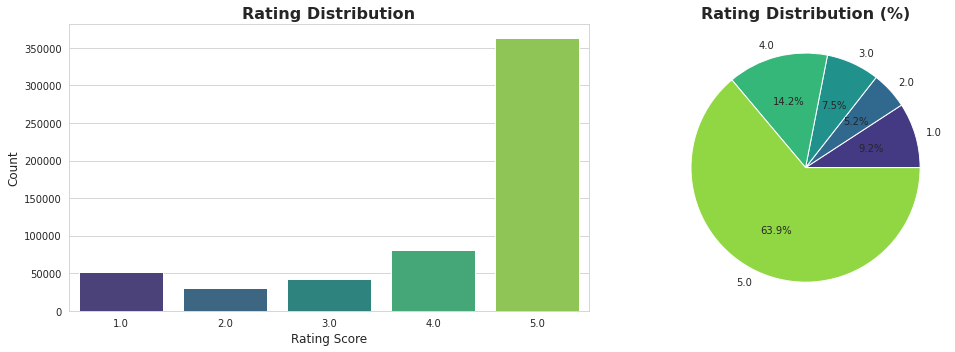


Rating Statistics:
1.0     52268
2.0     29769
3.0     42640
4.0     80655
5.0    363122
Name: review/score, dtype: int64


In [4]:
# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
sns.countplot(data=df, x='review/score', palette='viridis', ax=axes[0])
axes[0].set_title('Rating Distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Rating Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Pie chart
rating_counts = df['review/score'].value_counts().sort_index()
axes[1].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette('viridis', len(rating_counts)))
axes[1].set_title('Rating Distribution (%)', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRating Statistics:")
print(df['review/score'].value_counts().sort_index())

### Review Length Analysis

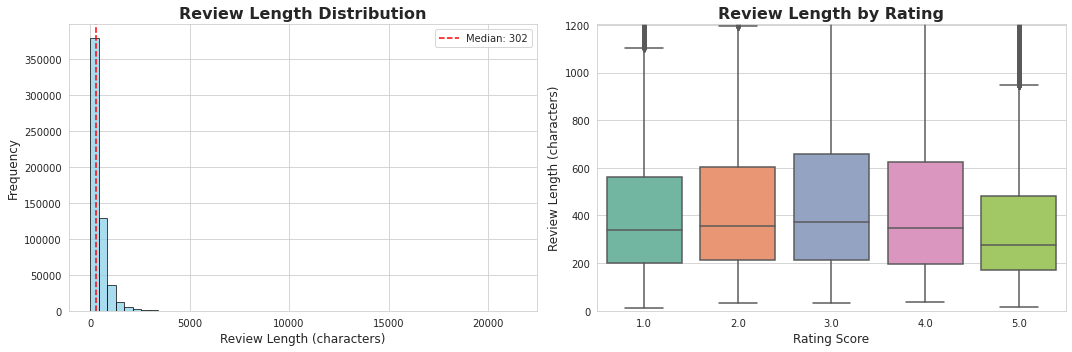

In [5]:
# Review length distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['ReviewLength'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Review Length Distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Review Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['ReviewLength'].median(), color='red', linestyle='--', label=f'Median: {df["ReviewLength"].median():.0f}')
axes[0].legend()

# Box plot by rating
sns.boxplot(data=df, x='review/score', y='ReviewLength', palette='Set2', ax=axes[1])
axes[1].set_title('Review Length by Rating', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Rating Score', fontsize=12)
axes[1].set_ylabel('Review Length (characters)', fontsize=12)
axes[1].set_ylim(0, df['ReviewLength'].quantile(0.95))

plt.tight_layout()
plt.show()

### Time Series Analysis

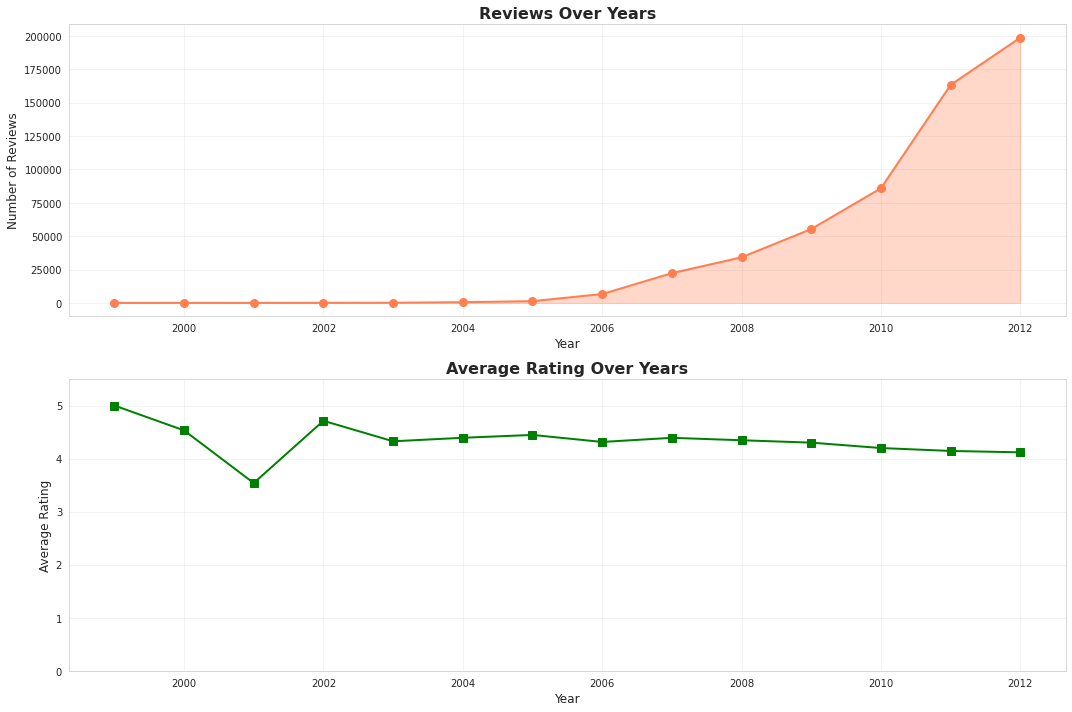

In [6]:
# Convert timestamp to datetime
df['Date'] = pd.to_datetime(df['review/time'], unit='s')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M')

# Reviews over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Reviews per year
yearly_reviews = df['Year'].value_counts().sort_index()
axes[0].plot(yearly_reviews.index, yearly_reviews.values, marker='o', linewidth=2, markersize=8, color='coral')
axes[0].fill_between(yearly_reviews.index, yearly_reviews.values, alpha=0.3, color='coral')
axes[0].set_title('Reviews Over Years', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Average rating over years
yearly_avg = df.groupby('Year')['review/score'].mean()
axes[1].plot(yearly_avg.index, yearly_avg.values, marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_title('Average Rating Over Years', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Average Rating', fontsize=12)
axes[1].set_ylim(0, 5.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Top Products & Users

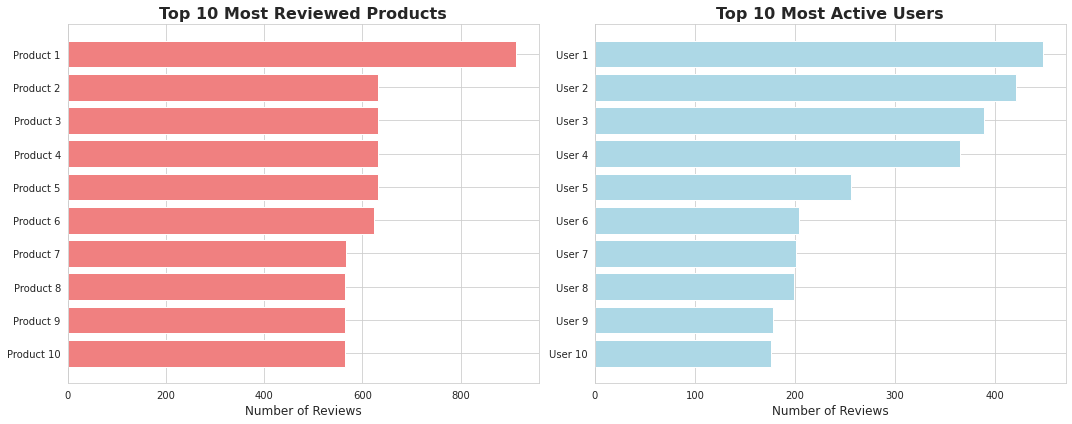


Most reviewed product has 913 reviews
Most active user wrote 448 reviews


In [7]:
# Top analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 products
top_products = df['product/productId'].value_counts().head(10)
axes[0].barh(range(len(top_products)), top_products.values, color='lightcoral')
axes[0].set_yticks(range(len(top_products)))
axes[0].set_yticklabels([f"Product {i+1}" for i in range(len(top_products))])
axes[0].set_title('Top 10 Most Reviewed Products', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Reviews', fontsize=12)
axes[0].invert_yaxis()

# Top 10 users
top_users = df['review/userId'].value_counts().head(10)
axes[1].barh(range(len(top_users)), top_users.values, color='lightblue')
axes[1].set_yticks(range(len(top_users)))
axes[1].set_yticklabels([f"User {i+1}" for i in range(len(top_users))])
axes[1].set_title('Top 10 Most Active Users', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Number of Reviews', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nMost reviewed product has {top_products.values[0]} reviews")
print(f"Most active user wrote {top_users.values[0]} reviews")

### Helpfulness Analysis

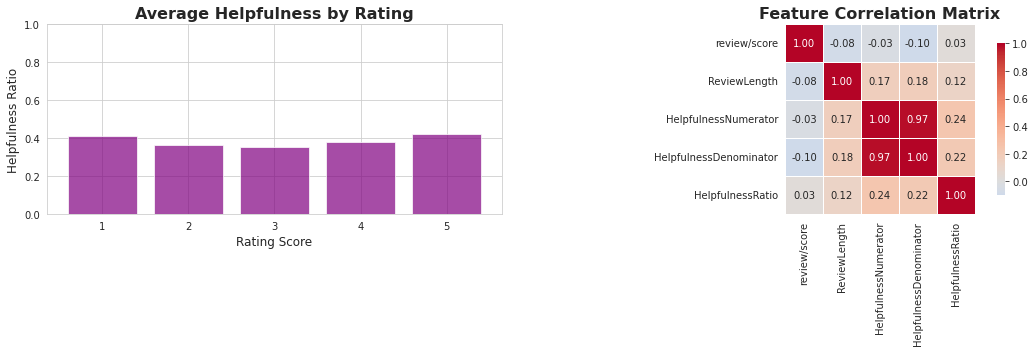

In [8]:
# Parse helpfulness ratio
df[['HelpfulnessNumerator', 'HelpfulnessDenominator']] = df['review/helpfulness'].str.split('/', expand=True)
df['HelpfulnessNumerator'] = pd.to_numeric(df['HelpfulnessNumerator'], errors='coerce')
df['HelpfulnessDenominator'] = pd.to_numeric(df['HelpfulnessDenominator'], errors='coerce')
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'].replace(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Helpfulness by rating
helpfulness_by_rating = df.groupby('review/score')['HelpfulnessRatio'].mean()
axes[0].bar(helpfulness_by_rating.index, helpfulness_by_rating.values, color='purple', alpha=0.7)
axes[0].set_title('Average Helpfulness by Rating', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Rating Score', fontsize=12)
axes[0].set_ylabel('Helpfulness Ratio', fontsize=12)
axes[0].set_ylim(0, 1)

# Correlation heatmap
corr_data = df[['review/score', 'ReviewLength', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']].corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Summary Statistics

In [9]:
# Summary dashboard
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\nTotal Reviews: {len(df):,}")
print(f"Total Products: {df['product/productId'].nunique():,}")
print(f"Total Users: {df['review/userId'].nunique():,}")
print(f"\nDate Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nRating Distribution:")
print(df['review/score'].value_counts(normalize=True).sort_index().apply(lambda x: f"{x*100:.1f}%"))
print(f"\nAverage Rating: {df['review/score'].mean():.2f}")
print(f"Median Rating: {df['review/score'].median():.0f}")
print(f"\nAverage Review Length: {df['ReviewLength'].mean():.0f} characters")
print(f"Median Review Length: {df['ReviewLength'].median():.0f} characters")
print("="*60)

DATASET SUMMARY

Total Reviews: 568,461
Total Products: 74,258
Total Users: 256,059

Date Range: 1999-10-08 to 2012-10-26

Rating Distribution:
1.0     9.2%
2.0     5.2%
3.0     7.5%
4.0    14.2%
5.0    63.9%
Name: review/score, dtype: object

Average Rating: 4.18
Median Rating: 5

Average Review Length: 436 characters
Median Review Length: 302 characters


## Phase 4: Data Cleaning

In [10]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nPercentage of missing values:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
product/productId         7
review/userId             7
review/profileName        7
review/helpfulness        7
review/score              7
review/time               7
review/summary            7
review/text               7
ReviewLength              0
Date                      7
Year                      7
Month                     7
HelpfulnessNumerator      7
HelpfulnessDenominator    7
HelpfulnessRatio          7
dtype: int64

Total missing values: 98

Percentage of missing values:
product/productId         0.0
review/userId             0.0
review/profileName        0.0
review/helpfulness        0.0
review/score              0.0
review/time               0.0
review/summary            0.0
review/text               0.0
ReviewLength              0.0
Date                      0.0
Year                      0.0
Month                     0.0
HelpfulnessNumerator      0.0
HelpfulnessDenominator    0.0
HelpfulnessRatio          0.0
dtype: float64


In [11]:
# Drop rows with missing values
df_clean = df.dropna()

print(f"Original dataset: {len(df):,} rows")
print(f"After cleaning: {len(df_clean):,} rows")
print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

Original dataset: 568,461 rows
After cleaning: 568,447 rows
Rows removed: 14

Missing values after cleaning:
0


## Phase 5: Collaborative Filtering Model

In [12]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
import pickle

# Prepare data for Surprise library
# Need: user_id, product_id, rating
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_clean[['review/userId', 'product/productId', 'review/score']], reader)

# Split into train/test (80/20)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Training set: {trainset.n_ratings:,} ratings")
print(f"Test set: {len(testset):,} ratings")
print(f"Number of users: {trainset.n_users:,}")
print(f"Number of products: {trainset.n_items:,}")

Training set: 454,757 ratings
Test set: 113,690 ratings
Number of users: 219,382
Number of products: 67,584


## Phase 6: Model Training

In [13]:
# Initialize SVD model
svd_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)

print("Training SVD model...")
print("This may take 5-10 minutes...")

# Train the model
svd_model.fit(trainset)

print("\n✓ Model training complete!")

Training SVD model...
This may take 5-10 minutes...

✓ Model training complete!


## Phase 7: Model Evaluation

In [14]:
# Make predictions on test set
predictions = svd_model.test(testset)

# Calculate accuracy metrics
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)

print("="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"RMSE (Root Mean Square Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print("\nInterpretation:")
print(f"On average, predictions are off by {mae:.2f} stars")
print("="*50)

MODEL EVALUATION
RMSE (Root Mean Square Error): 1.0845
MAE (Mean Absolute Error): 0.7895

Interpretation:
On average, predictions are off by 0.79 stars


### Saving model

In [15]:
# Create models directory
os.makedirs(os.path.expanduser('~/Desktop/Hireable/models/'), exist_ok=True)

# Save the trained model
model_path = os.path.expanduser('~/Desktop/Hireable/models/collab_filter.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(svd_model, f)

print(f"✓ Model saved to: {model_path}")

✓ Model saved to: /home/zigron/Desktop/Hireable/models/collab_filter.pkl


### Testing the model

In [16]:
# Test predictions for a sample user
sample_user = df_clean['review/userId'].iloc[0]
sample_product = df_clean['product/productId'].iloc[100]

# Predict rating
prediction = svd_model.predict(sample_user, sample_product)

print("SAMPLE PREDICTION TEST")
print("="*50)
print(f"User ID: {sample_user}")
print(f"Product ID: {sample_product}")
print(f"Predicted Rating: {prediction.est:.2f} stars")
print("="*50)

SAMPLE PREDICTION TEST
User ID: A3SGXH7AUHU8GW
Product ID: B004K2IHUO
Predicted Rating: 4.29 stars


## Phase 8: BERT Sentiment Analysis

In [17]:
import torch

# Check CUDA availability
print("="*50)
print("SYSTEM CHECK")
print("="*50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device("cuda")
    print(f"✓ Using GPU for training")
else:
    device = torch.device("cpu")
    print(f"⚠ Using CPU for training (will be slow)")
    
print(f"\nDevice selected: {device}")
print("="*50)

SYSTEM CHECK
PyTorch version: 2.9.1+cu128
CUDA available: False
⚠ Using CPU for training (will be slow)

Device selected: cpu


In [22]:
from transformers import DistilBertTokenizer
import numpy as np

# Initialize tokenizer
print("Loading tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Prepare texts and labels (FULL DATASET)
texts = df_clean['review/text'].tolist()
labels = df_clean['review/score'].astype(int).tolist()

# Convert ratings 1-5 to 0-4 for model (model expects 0-indexed classes)
labels = [l - 1 for l in labels]

print(f"Total samples: {len(texts):,}")
print(f"Label distribution: {np.bincount(labels)}")
print("✓ Data prepared for BERT training")


Loading tokenizer...
Total samples: 568,447
Label distribution: [ 52268  29768  42639  80654 363118]
✓ Data prepared for BERT training


### preparing data for bert

In [27]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(train_texts):,}")
print(f"Test samples: {len(test_texts):,}")
print("\nTrain label distribution:", np.bincount(train_labels))
print("Test label distribution:", np.bincount(test_labels))

Training samples: 454,757
Test samples: 113,690

Train label distribution: [ 41814  23815  34111  64523 290494]
Test label distribution: [10454  5953  8528 16131 72624]


In [28]:
print("Tokenizing training data...")
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)

print("Tokenizing test data...")
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

print("✓ Tokenization complete!")

Tokenizing training data...
Tokenizing test data...
✓ Tokenization complete!


In [29]:
import torch
from torch.utils.data import Dataset, DataLoader

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"✓ Datasets created")
print(f"Training batches: {len(train_loader):,}")
print(f"Test batches: {len(test_loader):,}")

✓ Datasets created
Training batches: 28,423
Test batches: 7,106


In [30]:
from transformers import DistilBertForSequenceClassification

# Load pre-trained DistilBERT for 5-class classification
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=5)
model.to(device)

print(f"✓ Model loaded and moved to {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded and moved to cpu
Model parameters: 66,957,317


In [32]:
from torch.optim import AdamW
from tqdm.auto import tqdm

# Optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Training parameters
num_epochs = 3  # 3 epochs is standard for BERT fine-tuning

print("Training configuration:")
print(f"Epochs: {num_epochs}")
print(f"Batch size: 16")
print(f"Learning rate: 5e-5")
print(f"Device: {device}")

Training configuration:
Epochs: 3
Batch size: 16
Learning rate: 5e-5
Device: cpu


#### model training

In [ ]:
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

model.train()
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
    
    for batch in progress_bar:
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Forward pass
        outputs = model(**batch)
        loss = outputs.loss
        
        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(train_loader)
    print(f"Average loss: {avg_loss:.4f}")

print("\n✓ Training complete!")


STARTING TRAINING

Epoch 1/3


Training Epoch 1:   0%|          | 0/28423 [00:00<?, ?it/s]

## Phase 9: Hybrid Recommendations

## Phase 10: Final Results